#**Chapter9. 비지도 학습**

오늘날 대부분의 머신러닝 에플리케이션이 지도 학습 기반이지만, 사용할 수 있는 데이터는 대부분 레이블이 없음. 즉, 입력 특성 X는 있지만 레이블 y는 없음.

그래서 모든 데이터에 레이블을 붙일 필요 없이 알고리즘이 레이블이 없는 데이터를 바로 사용할 수 있도록 비지도 학습이 필요.

8장에서 학습한 차원 축소를 제외하고 몇가지 비지도 학습과 알고리즘을 추가로 알아봄.

##**9.1 군집**

군집은 비슷한 샘플을 구별해 하나의 클러스터 또는 비슷한 샘플의 그룹으로 할당하는 작업.

클러스테에 대한 정의는 따로 없고, 알고리즘에 따라 다른 클러스터를 감지.

###**9.1.1 k-평균**

k-평균은 반복 몇 번으로 이런 종류의 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘.

In [56]:
# 데이터 불러오기
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

# 추가 코드 - make_blobs()의 정확한 인수는 중요하지 않습니다.
blob_centers = np.array([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8],[-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


각 샘플은 다섯 개의 클러스터 중 하나에 할당. 군집에서 각 샘플의 레이블은 알고리즘이 샘플에 할당한 클러스터의 인덱스.

In [57]:
y_pred

array([0, 0, 4, ..., 3, 1, 0], dtype=int32)

In [58]:
y_pred is kmeans.labels_

True

In [59]:
kmeans.cluster_centers_

array([[-2.80214068,  1.55162671],
       [ 0.08703534,  2.58438091],
       [-1.46869323,  2.28214236],
       [-2.79290307,  2.79641063],
       [ 0.31332823,  1.96822352]])

새로운 샘플에 가장 가까운 센트로이드의 클러스터를 할당할 수 있음.

In [60]:
X_new = np.array([[0,2],[3,2],[-3,3],[-3,2.5]])
kmeans.predict(X_new)

array([4, 4, 3, 3], dtype=int32)

샘플은 대부분 적절한 클러스터에 잘 할당됨. 하지만 샘플 몇개는 레이블이 잘못 부여됨.

하드 군집이라는 샘플을 하나의 클러스터에 할당하는 것보다 클러스터마다 샘플에 점수를 부여하는 것이 유용할 수 있음. 이를 소프트 군집이라고 함.

In [61]:
kmeans.transform(X_new)

array([[2.83778629, 0.59082671, 1.4955481 , 2.9042344 , 0.31493543],
       [5.81943941, 2.9710039 , 4.47759126, 5.84739223, 2.68685968],
       [1.4618254 , 3.11488787, 1.6912185 , 0.29040966, 3.47026031],
       [0.96879317, 3.08818836, 1.54672634, 0.36159148, 3.35573094]])

**[k-평균 알고리즘]**

데이터셋에 있는 모든 샘플에 가장 가까운 센트로이드의 클러스터를 할당할 수 있음.

하지만 레이블이나 센트로이드가 주어지지 않으면, 센트로이드를 랜덤하게 선정하고, 그 다음 샘플에 레이블을 할당하고 센트로이드를 업데이트하고, 샘플에 레이블을 할당하고 센트로이드를 업데이트하는 식으로 센트로이드에 변화가 없을 때까지 계속함.

**[센트로이드 초기화 방법]**

In [62]:
good_init = np.array([[-3,3],[-3,2],[-3,1],[-1,2],[0,2]])
kmeans = KMeans(n_clusters=5, init = good_init, n_init=1)

In [63]:
y_pred = kmeans.fit_predict(X)
kmeans.inertia_

211.59853725816828

In [64]:
kmeans.score(X)

-211.59853725816828

**[k-평균 속도 개선과 미니배치 k-평균]**

전체 데이터셋을 사용해 반복하지 않고 이 알고리즘은 각 반복마다 미니배치를 사용해 센트로이드를 조금씩 이동.

In [65]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MiniBatchKMeans(n_clusters=5)

**[최적의 클러스터 개수 찾기]**

일반적으로는 k를 어떻게 설정할지 쉽게 알 수 없음. 이를 정하는 더 정확한 방법은 실루엣 점수.

이 값은 모든 샘플에 대한 실루엣 계수의 평균. 실루엣 계수는 -1에서 +1까지 바뀔 수 있음. +1에 가까우면 자신의 클러스터 안에 잘 속해 있고 다른 클러스터와는 멀리 떨어져 있다는 뜻.

In [66]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.655517642572828

###**9.1.2 k-평균의 한계**

k-평균은 속도가 빠르고 확장이 용이하다는 장점이 많음. 하지만 최적이 아닌 솔루션을 피하려면 알고리즘을 여러 번 실행해야 함. 그리고 클러스터 개수도 지정해야 함.

###**9.1.3 군집을 사용한 이미지 분할**

이미지 분할은 이미지를 세그먼트 여러 개로 분할하는 작업. 시맨틱 분할에서는 동일한 종류의 물체에 속한 모든 픽셀은 같은 세그먼트에 할당.

시맨틱 또는 인스턴스 분할에서 최고 수준의 성능을 내려면 합성곱 신경망을 사용한 복잡한 모델을 사용해야 함.

In [67]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
image = plt.imread("/content/drive/MyDrive/2024_2학기/ESAA OB/필사 과제/ladybug.png")
image.shape

(533, 800, 3)

이미지는 3D 배열로 표현. (높이, 너비,컬러채널 개수)

흑백이미지는 더 적은 채널을 가지고, 알파 채널을 가진 이미지나 위성 이미지는 더 많은 채널을 가짐.

In [68]:
X = image.reshape(-1,3)
kmeans = KMeans(n_clusters=8).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


###**9.1.4 군집을 사용한 전처리**

군집은 차원축소에 효과적인 방법. 특히 지도 학습 알고리즘을 적용하기 전에 전처리 단계로 사용.

In [69]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y=True)

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

In [71]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [72]:
log_reg.score(X_test, y_test)

0.9644444444444444

In [73]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression()),
])
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [74]:
pipeline.score(X_test, y_test)

0.98

In [75]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(kmeans__n_clusters=range(2,100))
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Fitting 3 folds for each of 98 candidates, totalling 294 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[CV] END ...............................kmeans__n_clusters=2; total time=   0.3s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


...

[CV] END ..............................kmeans__n_clusters=99; total time=   1.4s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[CV] END ..............................kmeans__n_clusters=99; total time=   0.9s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [76]:
grid_clf.best_params_

{'kmeans__n_clusters': 78}

In [77]:
grid_clf.score(X_test, y_test)

0.98

###**9.1.5 군집을 사용한 준지도 학습**

레이블이 없는 데이터가 많고 레이블이 있는 데이터는 적을 때 사용함.

In [78]:
n_labeled = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_labeled],y_train[:n_labeled])

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [79]:
log_reg.score(X_test,y_test)

0.8377777777777777

In [80]:
k=50
kmeans = KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


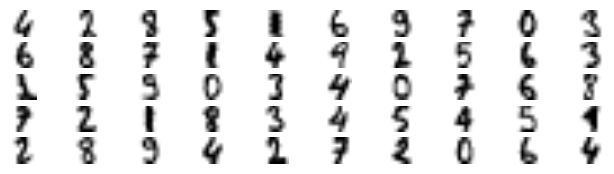

In [81]:
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",interpolation="bilinear")
    plt.axis('off')
plt.show()

In [82]:
y_representative_digits = np.array([8,5,8,3,0,6,9,3,4,9,7,5,1,2,5,2,1,4,5,7,9,3,5,6,4,2,0,8,4,6,8,7,1,9,6,5,9,7,8,0,7,6,3,3,8,4,7,5,2,7])

In [83]:
log_reg = LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.12

In [84]:
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [85]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.14222222222222222

In [86]:
percentile_closest=20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_==i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff]=-1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [87]:
log_reg = LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.11777777777777777

In [88]:
np.mean(y_train_partially_propagated == y_train[partially_propagated])

0.1103448275862069

###**9.1.6 DBSCAN**

이 알고리즘은 밀집된 연속적 지역을 클러스터로 정의. 모든 클러스터가 충분히 밀집되어 있고 밀집되지 않은 지역과 잘 구분될 때 좋은 성능을 냄.

In [89]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [90]:
dbscan.labels_

array([ 0, -1,  1,  0,  2,  0,  3,  0,  0,  3,  3,  0,  0,  4,  5, -1,  3,
        0,  0,  0, -1,  0,  0,  3,  0, -1,  6,  3,  3,  3, -1,  6,  0,  7,
        0,  0,  0,  8,  3,  6,  4,  7,  3,  0,  0,  7,  3,  7,  5,  1,  7,
        9,  5, -1,  0,  0,  5,  4,  0,  1, -1, -1,  0,  1,  4,  3,  3,  1,
        0,  3,  2,  3,  7,  2,  0,  0,  3,  6,  3,  0,  2,  1,  0,  0,  7,
        0,  2,  0, 10,  5, -1,  6,  7,  0,  9,  4,  3,  3,  5,  0,  2,  3,
        0,  0, -1,  7,  6,  3,  7,  7,  9,  3, -1,  0,  2,  1,  2,  1,  0,
        0,  7,  2,  0,  0,  1,  3,  7,  0,  5,  9,  1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  5,  6, -1,  3,  7,  8,  1,  0,  3,  7,  0,
        2,  7,  3,  3,  0,  7,  3,  0, -1,  8,  8,  0,  0,  0,  0,  3,  5,
        3,  0,  1,  4,  8,  0,  8,  7,  3,  0,  0,  0,  6,  0, -1,  2,  5,
        0,  7,  0,  3,  7,  0,  7,  7,  2,  1,  3,  0,  0,  7,  0,  0,  1,
        5,  5,  0,  0, -1,  1,  4,  6,  0, -1,  0,  7,  3,  0,  7,  5,  0,
        0,  7,  0,  6,  0

In [91]:
len(dbscan.core_sample_indices_)

781

In [92]:
dbscan.core_sample_indices_

array([  0,   2,   3,   4,   5,   7,   8,   9,  10,  12,  13,  14,  16,
        17,  18,  19,  22,  23,  24,  26,  27,  28,  29,  32,  33,  34,
        36,  37,  38,  40,  41,  43,  44,  46,  47,  48,  49,  50,  51,
        54,  55,  56,  57,  58,  59,  62,  63,  64,  65,  66,  67,  68,
        70,  71,  72,  73,  74,  76,  77,  78,  79,  81,  82,  83,  85,
        86,  87,  88,  89,  91,  92,  93,  95,  97,  98, 101, 102, 105,
       106, 107, 108, 109, 110, 113, 114, 115, 116, 117, 118, 120, 121,
       122, 123, 124, 125, 129, 130, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 142, 143, 145, 146, 148, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 162, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 180, 181, 182, 183, 186,
       187, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200,
       201, 202, 203, 204, 205, 206, 207, 209, 211, 212, 214, 215, 216,
       217, 219, 220, 221, 222, 224, 225, 226, 227, 228, 230, 23

In [93]:
dbscan.components_

array([[-0.73225136,  0.66063086],
       [ 0.89808881,  0.43973013],
       [ 0.13628809,  0.93633939],
       ...,
       [ 0.87524911,  0.5826857 ],
       [ 1.89144758,  0.09203116],
       [ 0.3966212 ,  0.95383367]])

DBSCAN클래스는 fit_predict()메서드만 제공. 이 알고리즘은 새로운 샘플에 대해 클러스터를 예측할 수 없음.

In [94]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [95]:
X_new = np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])
knn.predict(X_new)

array([0, 7, 1, 3])

In [96]:
knn.predict_proba(X_new)

array([[0.86, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 , 0.  , 0.04, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.4 , 0.3 , 0.3 , 0.  ],
       [0.  , 0.62, 0.16, 0.  , 0.  , 0.  , 0.22, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.58, 0.42, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

In [97]:
y_dist, y_pred_idx = knn.kneighbors(X_new,n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2]=-1
y_pred.ravel()

array([-1,  8,  1, -1])

###**9.1.7 다른 군집 알고리즘**

**[병합 군집]**

클러스터 계층을 밑바닥부터 위로 쌓아 구성. 반복마다 병합 군집은 인접한 클러스터 쌍을 연결.

**[BIRCH]**

특별히 대규모 데이터셋을 위해 고안. 특성 개수가 너무 많지 않다면 배치 k-평균보다 빠르고 비슷한 결과를 만듦.

**[평균-이동]**

이 알고리즘은 먼저 각 샘플을 중심으로 하는 원을 그림. 그다음 원마다 원에 포함된 모든 샘플의 평균을 구함.

**[유사도 전파]**

이 알고리즘은 투표 방식을 사용.

##**9.2 가우시안 혼합**

가우시안 혼합 모델은 샘플이 파라미터가 알려지지 않은 여러 개의 혼합된 가우시안 분포에서 생성되었다고 가정하는 확률모델. 하나의 가우시안 분포에서 생성된 모든 샘플은 하나의 클러스터를 형성. 일반적으로 이 클러스터는 타원형.

In [98]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10)

In [99]:
gm.weights_

array([0.58392363, 0.2074491 , 0.20862727])

In [100]:
gm.means_

array([[ 0.5009165 ,  0.2508017 ],
       [ 1.73491121, -0.06546681],
       [-0.7293787 ,  0.56766197]])

In [101]:
gm.covariances_

array([[[ 0.16270543, -0.09682965],
        [-0.09682965,  0.28434405]],

       [[ 0.05692763,  0.06560469],
        [ 0.06560469,  0.09245798]],

       [[ 0.05887627,  0.06610127],
        [ 0.06610127,  0.08938171]]])

이 클래스는 기댓값-최대화 알고리즘을 사용.

In [102]:
gm.converged_

True

In [103]:
gm.n_iter_

14

In [104]:
gm.predict(X)

array([2, 2, 0, 0, 0, 2, 1, 0, 2, 1, 1, 0, 2, 1, 0, 1, 1, 0, 2, 2, 2, 0,
       0, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1, 2,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 1, 2, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0, 0, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2,
       2, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 1, 0, 1, 2, 0, 1, 0, 2,
       0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       2, 2, 0, 2, 2, 0, 0, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0,
       2, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2,
       1, 0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2, 1, 1, 0, 1,
       0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 0, 1, 1,
       0, 2, 2, 2, 0, 2, 1, 0, 1, 2, 2, 0, 0, 0, 1,

In [105]:
gm.predict_proba(X)

array([[4.35982218e-003, 5.60861000e-188, 9.95640178e-001],
       [4.03692084e-004, 2.25543134e-200, 9.99596308e-001],
       [1.00000000e+000, 1.69919901e-030, 1.80309772e-064],
       ...,
       [1.00000000e+000, 2.51690214e-037, 4.53690398e-055],
       [5.59840126e-004, 9.99440160e-001, 3.43107570e-193],
       [1.00000000e+000, 2.38117100e-091, 1.14087554e-015]])

In [106]:
X_new, y_new = gm.sample(6)
X_new

array([[ 0.57719095, -0.85547236],
       [ 0.52164694,  0.40802551],
       [-0.58921861,  0.8291529 ],
       [-0.32766933,  1.10337257],
       [-0.68902737,  0.56883214],
       [-0.48185034,  0.97788855]])

In [107]:
y_new

array([0, 0, 2, 2, 2, 2])

주어진 위치에서 모델의 밀도를 추정할 수 있음. 이를 위해 score_samples() 메서드를 사용.샘플이 주어지면 이 메서드는 그 위치의 확률밀도함수의 로그를 예측.

In [108]:
gm.score_samples(X)

array([-1.95379363e-01, -1.56125707e+00, -1.60958995e+00, -1.61864869e+00,
       -1.64329815e+00, -1.48978442e+00, -9.44596124e-01, -2.16262142e+00,
       -6.88433736e-01, -8.38211049e-01, -2.57927267e-02, -1.93978122e+00,
       -2.57484278e+00, -7.86155708e-01, -1.60761448e+00, -2.02827884e+00,
       -4.40772341e-01, -2.18196511e+00, -8.57505362e-01, -1.01077638e+00,
       -1.91398343e+00, -1.89677945e+00, -1.57894231e+00, -6.46446458e-02,
       -1.27612230e+00, -2.07579219e+00, -2.21839836e+00, -5.97706682e-01,
       -4.21085132e-01, -4.76924455e-01, -2.17437444e+00, -2.18906748e+00,
       -6.97643443e-01, -1.40425335e+00, -1.56364002e+00, -1.97472506e+00,
       -1.99840660e+00, -1.34623160e+00, -6.65001435e-01, -2.21810508e+00,
       -1.30170715e+00, -1.57446919e+00, -1.29192705e+00, -1.68208777e-01,
       -1.56427954e+00, -1.74266877e+00, -2.43212324e-01, -1.38486987e+00,
       -1.53353265e+00, -1.49563075e+00, -1.67480370e+00, -1.55037005e+00,
       -1.34171915e+00, -

###**9.2.1 가우시안 혼합을 사용한 이상치 탐지**

이상치 탐지는 보통과 많이 다른 샘플을 감지하는 작업. 이를 이상치라고 부르고 보통 샘플은 정상치라고 함.

In [109]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities,4)
anomalies = X[densities < density_threshold]

특이치 탐지. 이 알고리즘은 이상치로 오염되지 않은 깨끗한 데이터셋에서 훈련하다는 것이 이상치 탐지와 다름.

###**9.2.2 클러스터 개수 선택하기**

k-평균에서는 이너셔나 실루엣 점수를 사용해 적절한 클러스터 개수를 선택. 가우시안 혼합에서는 이런 지표를 사용할 수 없음. 이런 지표들은 클러스터가 타원형이거나 크기가 다를 때 안정적이지 않기 때문. 대신 정의된 BIC나 AIC와 같은 이론적 정보 기준을 최소화하는 모델을 찾음.

In [110]:
gm.bic(X)

2757.822420906658

In [111]:
gm.aic(X)

2674.3905811639615

###**9.2.3 베이즈 가우시안 혼합 모델**

최적의 클러스터 개수를 수동으로 찾지 않고 불필요한 클러스터의 가중치를 0으로 만드는 BayesianGaussianMixture 클래스를 사용할 수 있음. 클러스터 개수 n_components를 최적의 클러스터 개수보다 크다고 믿을 만한 값으로 지정.

In [112]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=10)
bgm.fit(X)
np.round(bgm.weights_,2)

array([0.13, 0.12, 0.1 , 0.17, 0.17, 0.11, 0.11, 0.09, 0.  , 0.  ])

베타 분포는 고정 범위 안에 놓인 값을 가진 확률변수를 모델링할 때 자주 사용됨.